# 04 - Evaluate and Visualize

Compares four things on the same images, with identical preprocessing and
identical per-image target sizes:

1. **LR upsampled** - nearest neighbour, shows what the input really contains
2. **Bicubic** - the plain non-neural baseline
3. **Bicubic+calib** - bicubic plus a per-band sensor gain fitted on train only
4. **FlexScaleSR** - the trained network

against the **ground truth HR**.

**Why Bicubic+calib is here.** LR and HR come from different satellites, and LR
reads 18 to 41 percent brighter depending on the band. A neural network fixes
that automatically, so measuring it against plain bicubic hands it credit for
four multiplications. Bicubic+calib is the honest bar.

**Honesty rule.** Every number below comes from whatever checkpoint is actually
on disk. The notebook checks the checkpoint's provenance stamp and refuses to
label anything FINAL unless it came from a real full training run.

In [1]:
import sys, os, json

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data import list_pairs, load_pair
from src.metrics import (compute_all, compute_per_band, summarise,
                         dark_band_images)
from src.inference import (bicubic_upsample, predict, load_model, evaluate_split,
                           summary_table, save_prediction, fit_calibration,
                           calibrated_bicubic)
from src.train_utils import load_config, get_device, describe_checkpoint
from src.model import count_parameters
from src.visualize import comparison_panel, plot_history, error_map, to_rgb

cfg = load_config("configs/baseline.yaml")
HR_SCALE = cfg["data"]["hr_scale"]
device = get_device(cfg["training"]["device"])
CKPT = "checkpoints/best.pt"
FIG = "outputs/figures"
os.makedirs(FIG, exist_ok=True)
print("device:", device, "| checkpoint:", CKPT, "| exists:", os.path.exists(CKPT))

device: cuda | checkpoint: checkpoints/best.pt | exists: False


## Load the model, and check where it came from

A checkpoint file does not say on its face whether it came from a real training
run or a 30-second trial. Every checkpoint this project writes carries a
`run_type` stamp, and this notebook reads it before calling anything a result.

| what is on disk | what this notebook does |
|---|---|
| nothing | runs the baselines only |
| a trial checkpoint | runs everything, labels it **PROVISIONAL**, saves to `provisional_results.json` |
| a full-run checkpoint | labels it **FINAL**, saves to `final_results.json` |

In [2]:
model, IS_FINAL, ckpt = None, False, None

if not os.path.exists(CKPT):
    print("No checkpoint at " + CKPT + ".")
    print("Run section H of notebook 03 (full training), then re-run this notebook.")
else:
    text, IS_FINAL = describe_checkpoint(CKPT)
    model, ckpt_cfg, ckpt = load_model(CKPT, device=device)
    print("checkpoint provenance:")
    print("  " + text)
    print("  parameters: {:,}".format(count_parameters(model)))

MODEL_READY = model is not None
STATUS = "FINAL" if IS_FINAL else "PROVISIONAL"

print()
print("=" * 74)
if not MODEL_READY:
    print("STATUS: NO MODEL ON DISK - baseline results only.")
elif not IS_FINAL:
    print("STATUS: PROVISIONAL - this checkpoint is NOT from a full training run.")
    print("The numbers below demonstrate the pipeline. Do NOT report them.")
else:
    print("STATUS: FINAL - checkpoint came from a full training run on 100 images.")
print("=" * 74)

No checkpoint at checkpoints/best.pt.
Run section H of notebook 03 (full training), then re-run this notebook.

STATUS: NO MODEL ON DISK - baseline results only.


## Training curves

In [3]:
hist_path = "experiments/flexscalesr/history.csv"
if os.path.exists(hist_path):
    history = pd.read_csv(hist_path).to_dict("list")
    plot_history(history, save_path=os.path.join(FIG, "training_curves.png"))
    plt.show()
    best_ep = history["epoch"][int(np.argmax(history["val_psnr"]))]
    print("best val PSNR %.2f dB at epoch %d" % (max(history["val_psnr"]), best_ep))
    gap = history["train_loss"][-1] - history["val_loss"][-1]
    print("final train loss %.5f, val loss %.5f  (a large gap means overfitting)"
          % (history["train_loss"][-1], history["val_loss"][-1]))
else:
    print("No history file yet. Run section H of notebook 03.")

No history file yet. Run section H of notebook 03.


## Evaluate every method

Validation is what we tuned on. **Test is untouched data and is the final
number.** The calibration gains are fitted on the training split only, so
applying them to val and test leaks nothing.

In [4]:
gains = fit_calibration(".", split="train", hr_scale=HR_SCALE)
print("per-band gains fitted on train only:")
for b, g in zip(["Red", "Green", "Blue", "NIR"], gains):
    print("  %-6s %.4f" % (b, g))
print()

results = {}
for split in ["val", "test"]:
    per_image, per_band = evaluate_split(".", split, HR_SCALE, model, device,
                                         gains=gains)
    results[split] = (per_image, per_band)
    print("=== %s (%d images) ===" % (split, per_image.name.nunique()))
    print(summary_table(per_image).to_string())
    print()

METHODS = [m for m in ["Bicubic", "Bicubic+calib", "FlexScaleSR"]
           if m in results["test"][0].method.unique()]
M6 = ["psnr", "ssim", "mae", "rmse", "sam", "ergas"]

per-band gains fitted on train only:
  Red    0.7744
  Green  0.8020
  Blue   0.8496
  NIR    0.7107



=== val (20 images) ===
                  psnr    ssim     mae    rmse      sam    ergas
method                                                          
Bicubic        22.4922  0.6143  0.0688  0.0910   9.2655  36.9877
Bicubic+calib  24.9187  0.6480  0.0499  0.0676  10.6565  29.2532



=== test (20 images) ===
                  psnr    ssim     mae    rmse     sam    ergas
method                                                         
Bicubic        23.2522  0.6569  0.0505  0.0730  5.5178  10.6868
Bicubic+calib  25.6184  0.6828  0.0377  0.0555  6.2651   8.2605



## Summary table

PSNR and SSIM up is better. MAE, RMSE, SAM and ERGAS down is better.

In [5]:
for split in ["val", "test"]:
    per_image, _ = results[split]
    t = per_image.groupby("method")[M6].mean().reindex(METHODS)
    print("%s   [%s]" % (split.upper(), STATUS))
    print("Method           PSNR      SSIM      MAE       RMSE      SAM      ERGAS")
    print("-" * 74)
    for m, r in t.iterrows():
        print("%-14s  %7.3f   %7.4f   %7.4f   %7.4f   %7.3f   %7.3f"
              % (m, r.psnr, r.ssim, r.mae, r.rmse, r.sam, r.ergas))
    if MODEL_READY:
        for ref in ["Bicubic", "Bicubic+calib"]:
            d = t.loc["FlexScaleSR"] - t.loc[ref]
            verdict = "beats" if d.psnr > 0 else "does NOT beat"
            print("   vs %-14s PSNR %+6.3f  SSIM %+7.4f   -> FlexScaleSR %s it"
                  % (ref, d.psnr, d.ssim, verdict))
    print()

if MODEL_READY and not IS_FINAL:
    print("Reminder: STATUS is PROVISIONAL. These are not reportable results.")

VAL   [PROVISIONAL]
Method           PSNR      SSIM      MAE       RMSE      SAM      ERGAS
--------------------------------------------------------------------------
Bicubic          22.492    0.6143    0.0688    0.0910     9.265    36.988
Bicubic+calib    24.919    0.6480    0.0499    0.0676    10.656    29.253

TEST   [PROVISIONAL]
Method           PSNR      SSIM      MAE       RMSE      SAM      ERGAS
--------------------------------------------------------------------------
Bicubic          23.252    0.6569    0.0505    0.0730     5.518    10.687
Bicubic+calib    25.618    0.6828    0.0377    0.0555     6.265     8.261



## Mean, median and standard deviation

Read the ERGAS median, not the mean. ERGAS divides each band's error by that
band's mean, so a scene with a very dark band produces a huge value and drags
the average up.

In [6]:
per_image_test = results["test"][0]
display(per_image_test.groupby("method")[M6].agg(["mean", "median", "std"]).round(4))

dark = sorted(set(dark_band_images(per_image_test.to_dict("records"), 0.02)))
print("test scenes with a band mean below 0.02, where ERGAS is unreliable:",
      dark if dark else "none")

psnr                     ssim                     mae  \
                  mean   median     std    mean  median     std    mean   
method                                                                    
Bicubic        23.2522  23.2472  3.1838  0.6569  0.6690  0.1787  0.0505   
Bicubic+calib  25.6184  25.7785  3.1622  0.6828  0.7268  0.1755  0.0377   

                                 rmse                     sam                  \
               median     std    mean  median     std    mean  median     std   
method                                                                          
Bicubic        0.0487  0.0193  0.0730  0.0688  0.0251  5.5178  5.8957  2.5972   
Bicubic+calib  0.0370  0.0134  0.0555  0.0515  0.0182  6.2651  6.2450  2.4994   

                 ergas                  
                  mean  median     std  
method                                  
Bicubic        10.6868  8.9296  6.1640  
Bicubic+calib   8.2605  7.3270  4.2359

test scenes with a band mean below 0.02, where ERGAS is unreliable: ['8.tif']


## Per-band results

The four bands are not equally easy. NIR is the hardest: it is the brightest
band, so the same relative error is a larger absolute error, and the two
sensors' NIR filters differ most.

psnr    ssim     mae    rmse
method        band                                  
Bicubic       Blue   31.4888  0.7630  0.0253  0.0351
              Green  27.7551  0.7012  0.0369  0.0476
              NIR    19.9584  0.4870  0.0957  0.1120
              Red    27.1963  0.6764  0.0442  0.0567
Bicubic+calib Blue   32.0203  0.7775  0.0219  0.0314
              Green  29.5689  0.7335  0.0284  0.0390
              NIR    21.8510  0.5182  0.0679  0.0844
              Red    29.1740  0.7022  0.0327  0.0450

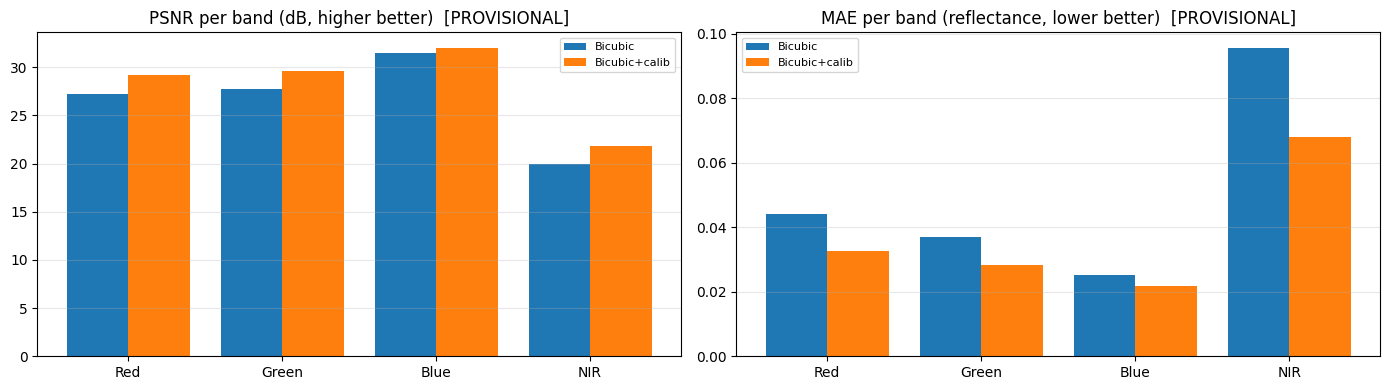

In [7]:
_, per_band_test = results["test"]
pb = (per_band_test.groupby(["method", "band"])[["psnr", "ssim", "mae", "rmse"]]
      .mean().round(4))
display(pb)

order = ["Red", "Green", "Blue", "NIR"]
xs = np.arange(4)
w = 0.8 / len(METHODS)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for i, m in enumerate(METHODS):
    sub = per_band_test[per_band_test.method == m]
    ax[0].bar(xs + i * w, [sub[sub.band == b].psnr.mean() for b in order], w, label=m)
    ax[1].bar(xs + i * w, [sub[sub.band == b].mae.mean() for b in order], w, label=m)
for a, t in zip(ax, ["PSNR per band (dB, higher better)",
                     "MAE per band (reflectance, lower better)"]):
    a.set_xticks(xs + w * (len(METHODS) - 1) / 2)
    a.set_xticklabels(order); a.set_title(t + "  [" + STATUS + "]")
    a.legend(fontsize=8); a.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "per_band_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()

## Per-image results

In [8]:
wide = per_image_test.pivot(index="name", columns="method", values="psnr").round(3)
wide = wide[METHODS]
if MODEL_READY:
    wide["gain_vs_bicubic"] = (wide["FlexScaleSR"] - wide["Bicubic"]).round(3)
    wide["gain_vs_calib"] = (wide["FlexScaleSR"] - wide["Bicubic+calib"]).round(3)
    wide = wide.sort_values("gain_vs_calib")
display(wide)

if MODEL_READY:
    print("FlexScaleSR beats plain bicubic on %d of %d test images."
          % (int((wide.gain_vs_bicubic > 0).sum()), len(wide)))
    print("FlexScaleSR beats CALIBRATED bicubic on %d of %d test images."
          % (int((wide.gain_vs_calib > 0).sum()), len(wide)))

method,Bicubic,Bicubic+calib
name,,
1.tif,23.514,32.114
10.tif,22.089,21.559
11.tif,30.914,24.368
12.tif,19.207,22.331
13.tif,24.730,23.860
14.tif,24.139,26.277
15.tif,19.973,23.012
16.tif,18.199,21.137
17.tif,22.397,26.604


## Comparison plots

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21172\1437166831.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot(data, labels=[k.replace("Bicubic+calib", "Bic+cal") for k in METHODS])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21172\1437166831.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot(data, labels=[k.replace("Bicubic+calib", "Bic+cal") for k in METHODS])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21172\1437166831.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot(data, labels=[k.replace("Bicubic+calib", "Bic+cal") for k in METHODS])


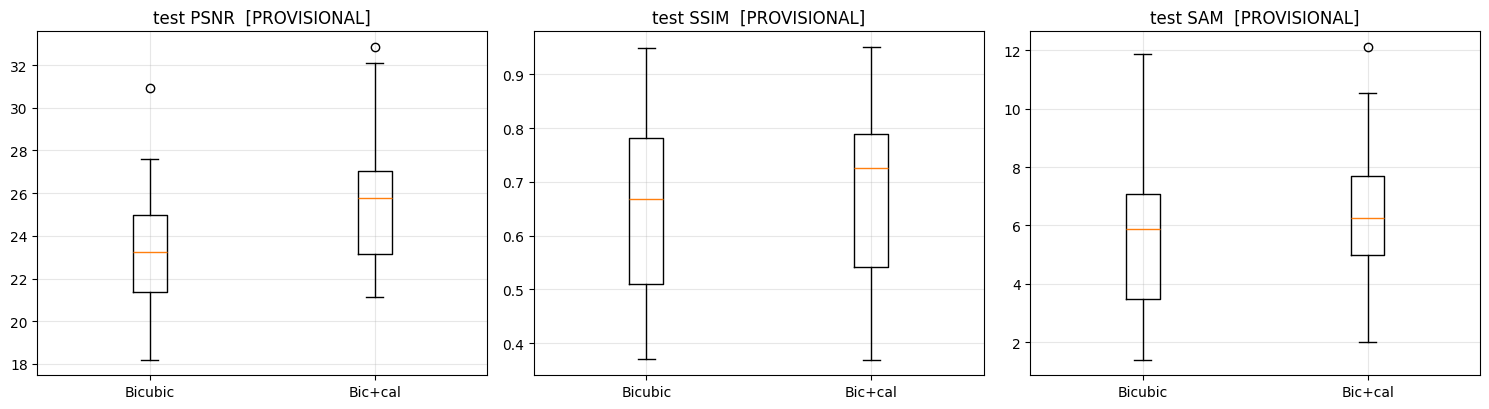

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for a, m in zip(ax, ["psnr", "ssim", "sam"]):
    data = [per_image_test[per_image_test.method == k][m] for k in METHODS]
    a.boxplot(data, labels=[k.replace("Bicubic+calib", "Bic+cal") for k in METHODS])
    a.set_title("test " + m.upper() + "  [" + STATUS + "]"); a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG, "metric_boxplots.png"), dpi=120, bbox_inches="tight")
plt.show()

In [10]:
if MODEL_READY:
    ref = per_image_test[per_image_test.method == "Bicubic+calib"].set_index("name").psnr
    net = per_image_test[per_image_test.method == "FlexScaleSR"].set_index("name").psnr
    net = net.reindex(ref.index)
    lim = [min(ref.min(), net.min()) - 0.5, max(ref.max(), net.max()) + 0.5]
    plt.figure(figsize=(5.6, 5.6))
    plt.scatter(ref, net, s=45)
    plt.plot(lim, lim, "k--", lw=1, label="equal performance")
    plt.xlabel("Bicubic+calib PSNR (dB)"); plt.ylabel("FlexScaleSR PSNR (dB)")
    plt.title("per-image PSNR, test split  [" + STATUS + "]\n"
              "points above the line = the network wins")
    plt.legend(); plt.grid(alpha=0.3); plt.xlim(lim); plt.ylim(lim)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, "psnr_scatter.png"), dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No model loaded, skipping the scatter plot.")

No model loaded, skipping the scatter plot.


## Visual comparison panels

Top row RGB, bottom row NIR. All panels share one stretch taken from the ground
truth, so the comparison is visual as well as numeric.

We show the **worst** cases as well as the best. Showing only successes would
misrepresent the model.

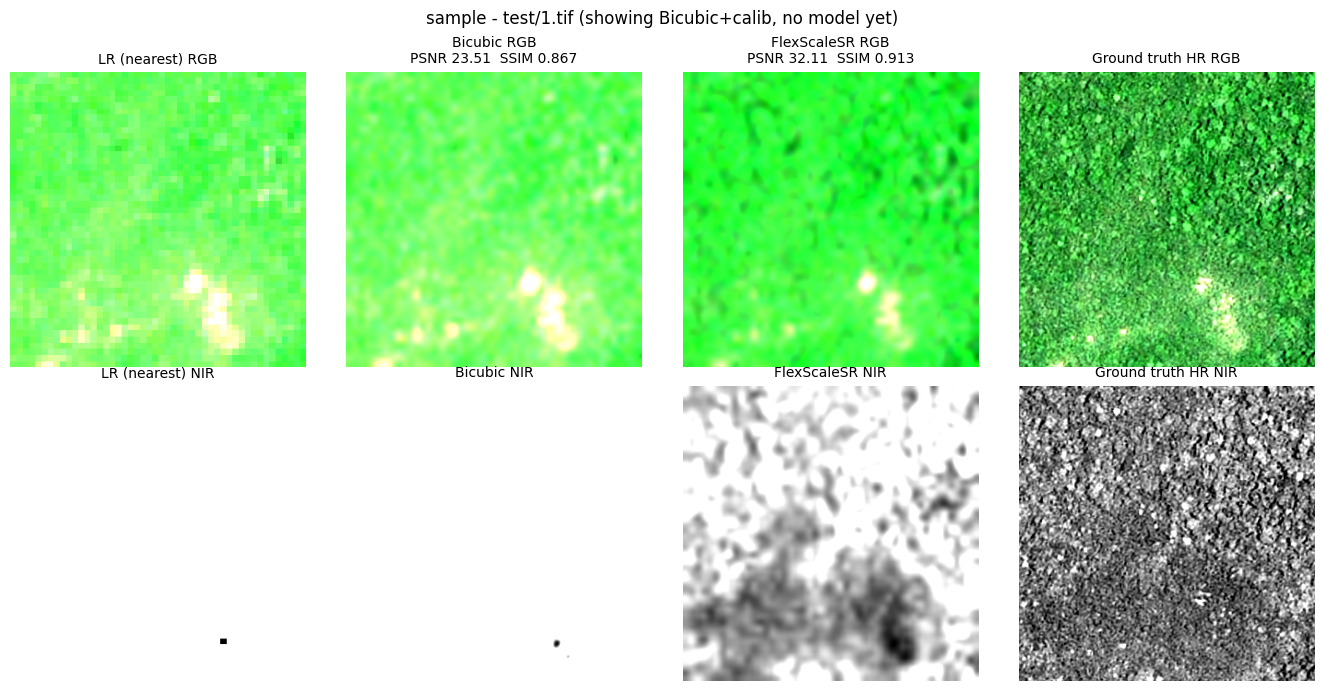

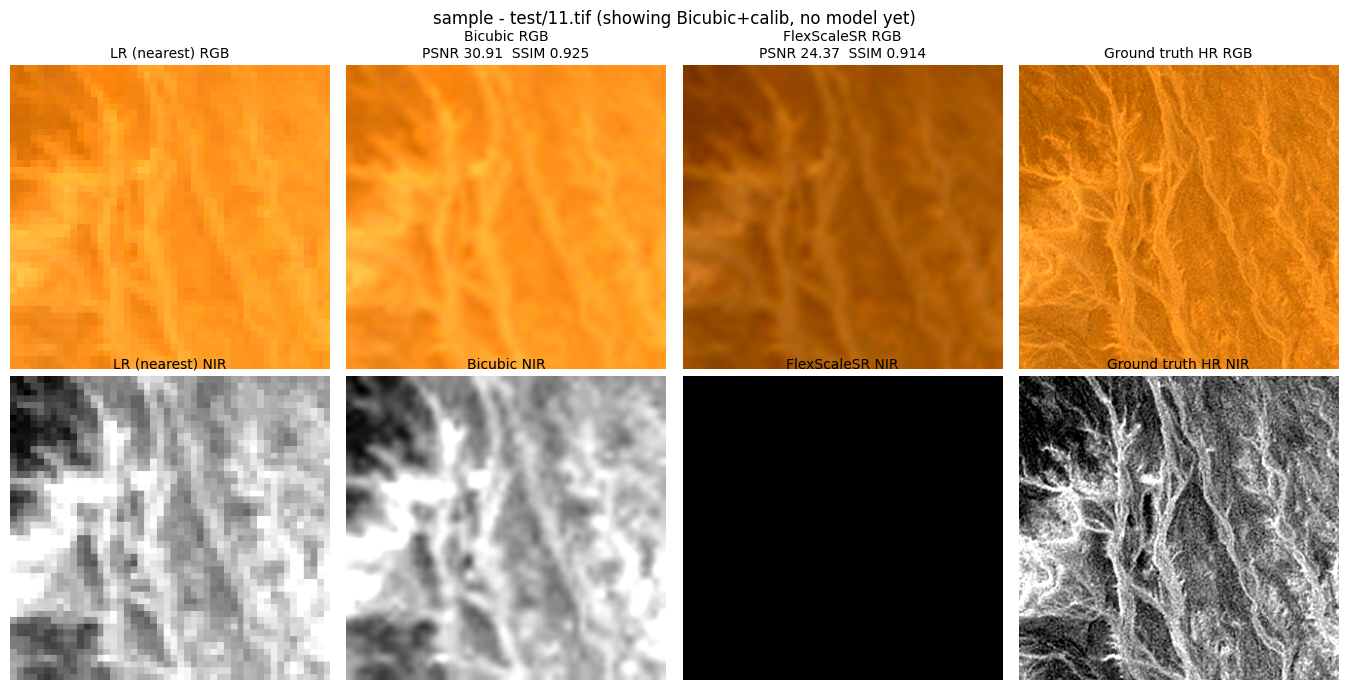

In [11]:
if MODEL_READY:
    key = wide["gain_vs_calib"]
    picks = [("worst case", key.index[0]),
             ("second worst", key.index[1]),
             ("typical case", key.index[len(key) // 2]),
             ("best case", key.index[-1])]
else:
    names = [n for n, _, _ in list_pairs(".", "test")]
    picks = [("sample", names[0]), ("sample", names[len(names) // 2])]

for label, name in picks:
    lr_i, hr_i = load_pair("test/LR/" + name, "test/HR/" + name, HR_SCALE)
    hw = hr_i.shape[:2]
    bic_i = bicubic_upsample(lr_i, hw)
    net_i = predict(model, lr_i, hw, device) if MODEL_READY else \
        calibrated_bicubic(lr_i, hw, gains)
    title = ("%s - test/%s   [%s]" % (label, name, STATUS)) if MODEL_READY \
        else ("%s - test/%s (showing Bicubic+calib, no model yet)" % (label, name))
    m = {"Bicubic": compute_all(bic_i, hr_i, (48, 48)),
         "FlexScaleSR": compute_all(net_i, hr_i, (48, 48))}
    comparison_panel(lr_i, bic_i, net_i, hr_i, name=title, metrics=m,
                     save_path=os.path.join(
                         FIG, "panel_%s_%s.png" % (label.replace(" ", "_"), name)))
    plt.show()

## Failure analysis

Where is the model wrong, and in which band? Bright areas are where the
prediction misses the truth.

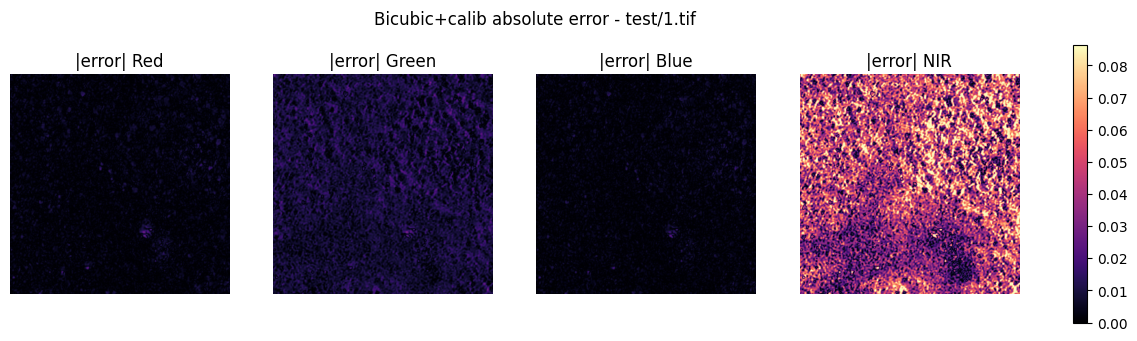

mean absolute error by band on this scene:
band       bicubic  bic+calib    network
Red         0.0056     0.0024        nan
Green       0.0183     0.0084        nan
Blue        0.0039     0.0022        nan
NIR         0.1286     0.0427        nan


In [12]:
worst = picks[0][1]
lr_i, hr_i = load_pair("test/LR/" + worst, "test/HR/" + worst, HR_SCALE)
hw = hr_i.shape[:2]
bic_i = bicubic_upsample(lr_i, hw)
cal_i = calibrated_bicubic(lr_i, hw, gains)
net_i = predict(model, lr_i, hw, device) if MODEL_READY else None

error_map(cal_i, hr_i, name="Bicubic+calib absolute error - test/" + worst,
          save_path=os.path.join(FIG, "error_calib_" + worst + ".png"))
plt.show()
if MODEL_READY:
    error_map(net_i, hr_i, name="FlexScaleSR absolute error - test/" + worst,
              save_path=os.path.join(FIG, "error_flexscalesr_" + worst + ".png"))
    plt.show()

print("mean absolute error by band on this scene:")
print("%-7s %10s %10s %10s" % ("band", "bicubic", "bic+calib", "network"))
for c, b in enumerate(["Red", "Green", "Blue", "NIR"]):
    n = np.abs(net_i[..., c] - hr_i[..., c]).mean() if MODEL_READY else float("nan")
    print("%-7s %10.4f %10.4f %10.4f"
          % (b, np.abs(bic_i[..., c] - hr_i[..., c]).mean(),
             np.abs(cal_i[..., c] - hr_i[..., c]).mean(), n))

### Reflectance distributions

A brightness bias shows up here as a shifted histogram. This is the clearest
picture of the sensor mismatch and of whether it has been corrected.

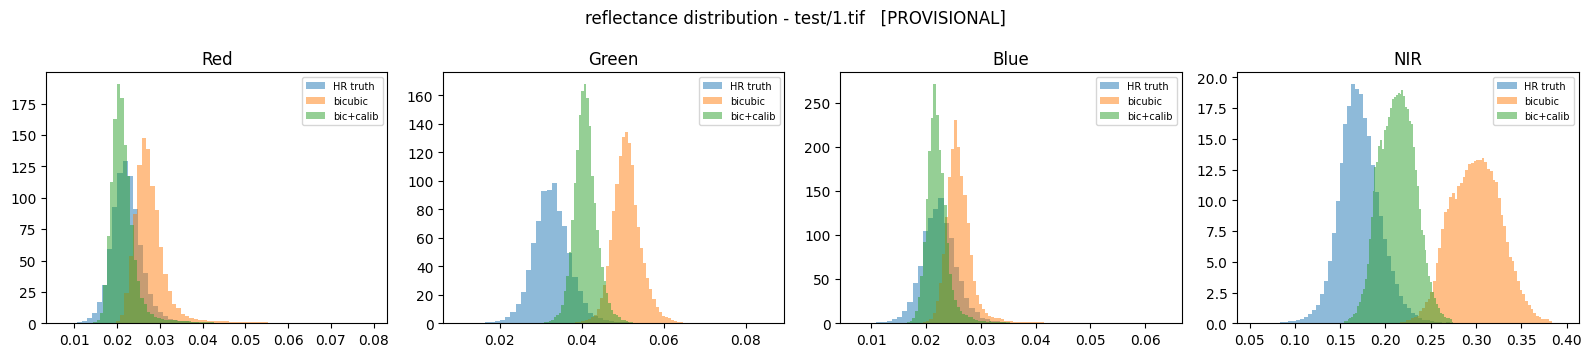

In [13]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3.6))
for c, b in enumerate(["Red", "Green", "Blue", "NIR"]):
    ax[c].hist(hr_i[..., c].ravel(), bins=60, alpha=0.5, label="HR truth", density=True)
    ax[c].hist(bic_i[..., c].ravel(), bins=60, alpha=0.5, label="bicubic", density=True)
    ax[c].hist(cal_i[..., c].ravel(), bins=60, alpha=0.5, label="bic+calib", density=True)
    if MODEL_READY:
        ax[c].hist(net_i[..., c].ravel(), bins=60, alpha=0.5,
                   label="FlexScaleSR", density=True)
    ax[c].set_title(b); ax[c].legend(fontsize=7)
fig.suptitle("reflectance distribution - test/" + worst + "   [" + STATUS + "]")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "reflectance_histograms.png"), dpi=120, bbox_inches="tight")
plt.show()

## Write predictions to disk

Predicted GeoTIFFs: float32 reflectance, 4 bands in `[R, G, B, NIR]` order, at
the exact HR size, carrying the geotransform of the matching HR file.

In [14]:
if MODEL_READY:
    PRED_DIR = "outputs/predictions/test"
    evaluate_split(".", "test", HR_SCALE, model, device, save_tif_dir=PRED_DIR)
    files = sorted(os.listdir(PRED_DIR))
    print("wrote %d GeoTIFFs to %s" % (len(files), PRED_DIR))

    import tifffile
    from src.data import geo_info
    chk = tifffile.imread(os.path.join(PRED_DIR, files[0]))
    ref = tifffile.imread("test/HR/" + files[0])
    print()
    print("check %s: shape %s dtype %s | HR shape %s"
          % (files[0], chk.shape, chk.dtype, ref.shape))
    print("sizes match       :", chk.shape == ref.shape)
    print("4 bands preserved :", chk.shape[2] == 4)
    print("geo tags kept     :", geo_info(os.path.join(PRED_DIR, files[0]))["epsg"])
    print("within [0, %.1f]  : %s" % (cfg["model"]["max_reflectance"],
                                      bool(chk.min() >= 0 and
                                           chk.max() <= cfg["model"]["max_reflectance"] + 1e-6)))
else:
    print("No model loaded, skipping prediction export.")

No model loaded, skipping prediction export.


## Save the evaluation results

The filename itself records whether these are final numbers.

In [15]:
OUT = "experiments/flexscalesr"
os.makedirs(OUT, exist_ok=True)

for split in ["val", "test"]:
    pi, pbnd = results[split]
    pi.to_csv(os.path.join(OUT, "metrics_per_image_%s.csv" % split), index=False)
    pbnd.to_csv(os.path.join(OUT, "metrics_per_band_%s.csv" % split), index=False)

payload = {
    "status": STATUS,
    "checkpoint": CKPT if MODEL_READY else None,
    "checkpoint_run": ckpt.get("run", {}) if MODEL_READY else None,
    "parameters": int(count_parameters(model)) if MODEL_READY else None,
    "hr_scale": HR_SCALE,
    "canonical_band_order": ["R", "G", "B", "NIR"],
    "calibration_gains": dict(zip(["Red", "Green", "Blue", "NIR"],
                                  [float(g) for g in gains])),
    "results": {s: {m: summarise(g.to_dict("records"))
                    for m, g in results[s][0].groupby("method")}
                for s in ["val", "test"]},
}
fname = "final_results.json" if IS_FINAL else "provisional_results.json"
with open(os.path.join(OUT, fname), "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print("saved as", os.path.join(OUT, fname))
if not IS_FINAL:
    print("Note the filename: these are NOT final results.")
for f in sorted(os.listdir(OUT)):
    print("   ", os.path.join(OUT, f))
print("figures in", FIG)

saved as experiments/flexscalesr\provisional_results.json
Note the filename: these are NOT final results.
    experiments/flexscalesr\metrics_per_band_test.csv
    experiments/flexscalesr\metrics_per_band_val.csv
    experiments/flexscalesr\metrics_per_image_test.csv
    experiments/flexscalesr\metrics_per_image_val.csv
    experiments/flexscalesr\provisional_results.json
figures in outputs/figures


## Conclusion

Fill this in from the numbers actually printed above, and only once STATUS reads
FINAL.

Three numbers matter, in this order:

1. **Plain bicubic** test PSNR - the naive baseline.
2. **Bicubic+calib** test PSNR - the honest baseline. About 43 percent of plain
   bicubic's squared error is a global sensor brightness mismatch that four
   multiplications remove.
3. **FlexScaleSR** test PSNR - and specifically whether it beats number 2, not
   just number 1.

Beating plain bicubic is not evidence of super-resolution. Beating the
calibrated bicubic is, because that is the part of the gap that requires
inventing real spatial detail.

If FlexScaleSR does not beat Bicubic+calib, report that plainly. The causes
worth checking, in order:

1. Too few epochs, or early stopping fired too soon.
2. 100 training pairs is very few. Random paired crops would multiply the
   effective dataset size.
3. Loss weights need tuning: more gradient weight for sharpness, more SAM weight
   for spectral fidelity.
4. The per-image radiometric variation is large. A per-scene correction reaches
   far higher PSNR than a global one, which suggests giving the model an
   explicit brightness-correction pathway.

Only after the calibrated baseline is genuinely beaten is it worth adding
channel attention, RCAN-style blocks, or a transformer backbone.